In [45]:
import os
from pathlib import Path
import kagglehub
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
import torchvision.models as models
from torchsummary import summary
import evaluate
from PIL import Image, ImageFile
from tqdm import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import copy
import mlflow
import mlflow.pytorch
import dagshub

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

In [3]:
dagshub.init(repo_owner='RichardHolzhofer', repo_name='tomato_disease_detection_project', mlflow=True)

Initialized MLflow to track repo "RichardHolzhofer/tomato_disease_detection_project"

Repository RichardHolzhofer/tomato_disease_detection_project initialized!

#### Downloading dataset

In [4]:
kaggle_path = kagglehub.dataset_download("cookiefinder/tomato-disease-multiple-sources")

print("Path to dataset files:", kaggle_path)

Path to dataset files: C:\Users\hrichard\.cache\kagglehub\datasets\cookiefinder\tomato-disease-multiple-sources\versions\1


In [ ]:
dataset_path = Path(kaggle_path)
print(f"Dataset downloaded to: {dataset_path}")

WindowsPath('C:/Users/hrichard/.cache/kagglehub/datasets/cookiefinder/tomato-disease-multiple-sources/versions/1')

In [6]:
os.listdir(dataset_path)

['train', 'valid']

In [7]:
# Using validation set as test set for performance evaluation
train_folder_path = os.path.join(dataset_path, "train")
test_folder_path = os.path.join(dataset_path, "valid")

In [8]:
def get_dataset_info(path):
    data = []

    folder_path = Path(path)

    # Loop through subdirectories (disease classes)
    for class_dir in folder_path.iterdir():
        if class_dir.is_dir():
            label = class_dir.name
            # Loop through image files in the class directory
            for filepath in class_dir.iterdir():
                if filepath.is_file() and filepath.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                    data.append({'path': str(filepath), 'label': label})

    df = pd.DataFrame(data)
    return df

In [9]:
train_dataset = get_dataset_info(train_folder_path)
print("Train dataset:\n\n", train_dataset["label"].value_counts())

Train dataset:

 label
Late_blight                             3113
healthy                                 3051
Septoria_leaf_spot                      2882
Bacterial_spot                          2826
Leaf_Mold                               2754
Early_blight                            2455
Tomato_mosaic_virus                     2153
Tomato_Yellow_Leaf_Curl_Virus           2039
Target_Spot                             1827
Spider_mites Two-spotted_spider_mite    1747
powdery_mildew                          1004
Name: count, dtype: int64


In [10]:
test_df = get_dataset_info(test_folder_path)
print("Test dataset:\n\n", test_df["label"].value_counts())

Test dataset:

 label
healthy                                 806
Late_blight                             792
Septoria_leaf_spot                      746
Leaf_Mold                               739
Bacterial_spot                          732
Early_blight                            643
Tomato_mosaic_virus                     584
Tomato_Yellow_Leaf_Curl_Virus           498
Target_Spot                             457
Spider_mites Two-spotted_spider_mite    435
powdery_mildew                          252
Name: count, dtype: int64


In [11]:
def create_label_to_id(df):
    label_to_id = {name: id for id, name in enumerate(sorted(df["label"].unique()))}
    return label_to_id

In [12]:
train_and_validation_classes = create_label_to_id(train_dataset)

print(pd.Series(train_and_validation_classes))

Bacterial_spot                           0
Early_blight                             1
Late_blight                              2
Leaf_Mold                                3
Septoria_leaf_spot                       4
Spider_mites Two-spotted_spider_mite     5
Target_Spot                              6
Tomato_Yellow_Leaf_Curl_Virus            7
Tomato_mosaic_virus                      8
healthy                                  9
powdery_mildew                          10
dtype: int64


In [13]:
test_classes = create_label_to_id(test_df)

print(pd.Series(test_classes))

Bacterial_spot                           0
Early_blight                             1
Late_blight                              2
Leaf_Mold                                3
Septoria_leaf_spot                       4
Spider_mites Two-spotted_spider_mite     5
Target_Spot                              6
Tomato_Yellow_Leaf_Curl_Virus            7
Tomato_mosaic_virus                      8
healthy                                  9
powdery_mildew                          10
dtype: int64


In [14]:
from sklearn.model_selection import train_test_split

# Split train_dataset into train and validation sets
train_df, valid_df = train_test_split(train_dataset, test_size=0.25, random_state=42, stratify=train_dataset['label'])

print("Train set size:", len(train_df))
print("Validation set size:", len(valid_df))
print("Test set size:", len(test_df))
print("\nTrain set class distribution:\n", train_df['label'].value_counts())
print("\nValidation set class distribution:\n", valid_df['label'].value_counts())
print("\nTest set class distribution:\n", test_df['label'].value_counts())

Train set size: 19388
Validation set size: 6463
Test set size: 6684

Train set class distribution:
 label
Late_blight                             2335
healthy                                 2288
Septoria_leaf_spot                      2161
Bacterial_spot                          2120
Leaf_Mold                               2066
Early_blight                            1841
Tomato_mosaic_virus                     1615
Tomato_Yellow_Leaf_Curl_Virus           1529
Target_Spot                             1370
Spider_mites Two-spotted_spider_mite    1310
powdery_mildew                           753
Name: count, dtype: int64

Validation set class distribution:
 label
Late_blight                             778
healthy                                 763
Septoria_leaf_spot                      721
Bacterial_spot                          706
Leaf_Mold                               688
Early_blight                            614
Tomato_mosaic_virus                     538
Tomato_Yellow_Leaf_Cur

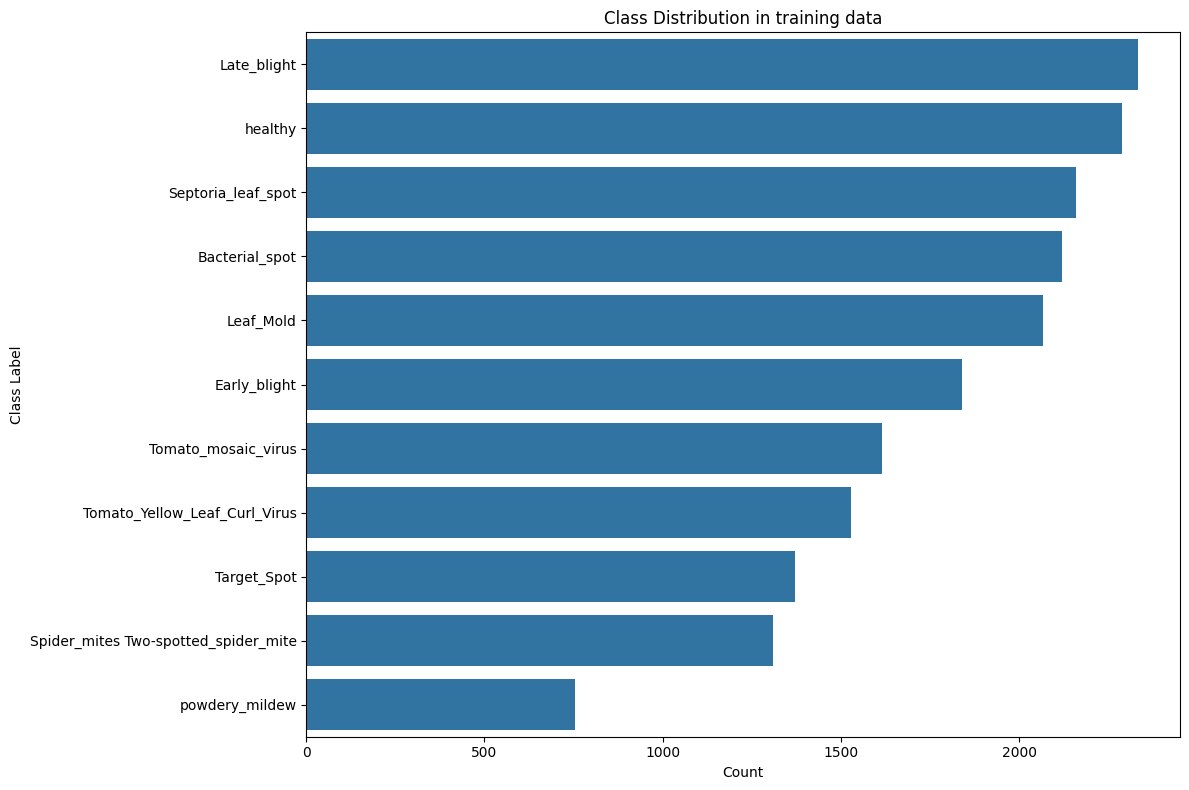

In [15]:
plt.figure(figsize=(12, 8))
order = train_df['label'].value_counts().index
sns.countplot(data=train_df, y='label', order=order)
plt.title('Class Distribution in training data')
plt.xlabel('Count')
plt.ylabel('Class Label')
plt.tight_layout()
plt.show()

In [16]:
def show_samples(df, num_samples=9):
    if df.empty:
        print("No data to visualize.")
        return
        
    plt.figure(figsize=(15, 12))
    # Sample random images
    sample_df = df.sample(min(num_samples, len(df)))
    
    for i, (_, row) in enumerate(sample_df.iterrows()):
        try:
            img = Image.open(row['path'])
            plt.subplot(3, 3, i + 1)
            plt.imshow(img)
            plt.title(row['label'])
            plt.axis('off')
        except Exception as e:
            print(f"Error loading image {row['path']}: {e}")
            
    plt.tight_layout()
    plt.show()

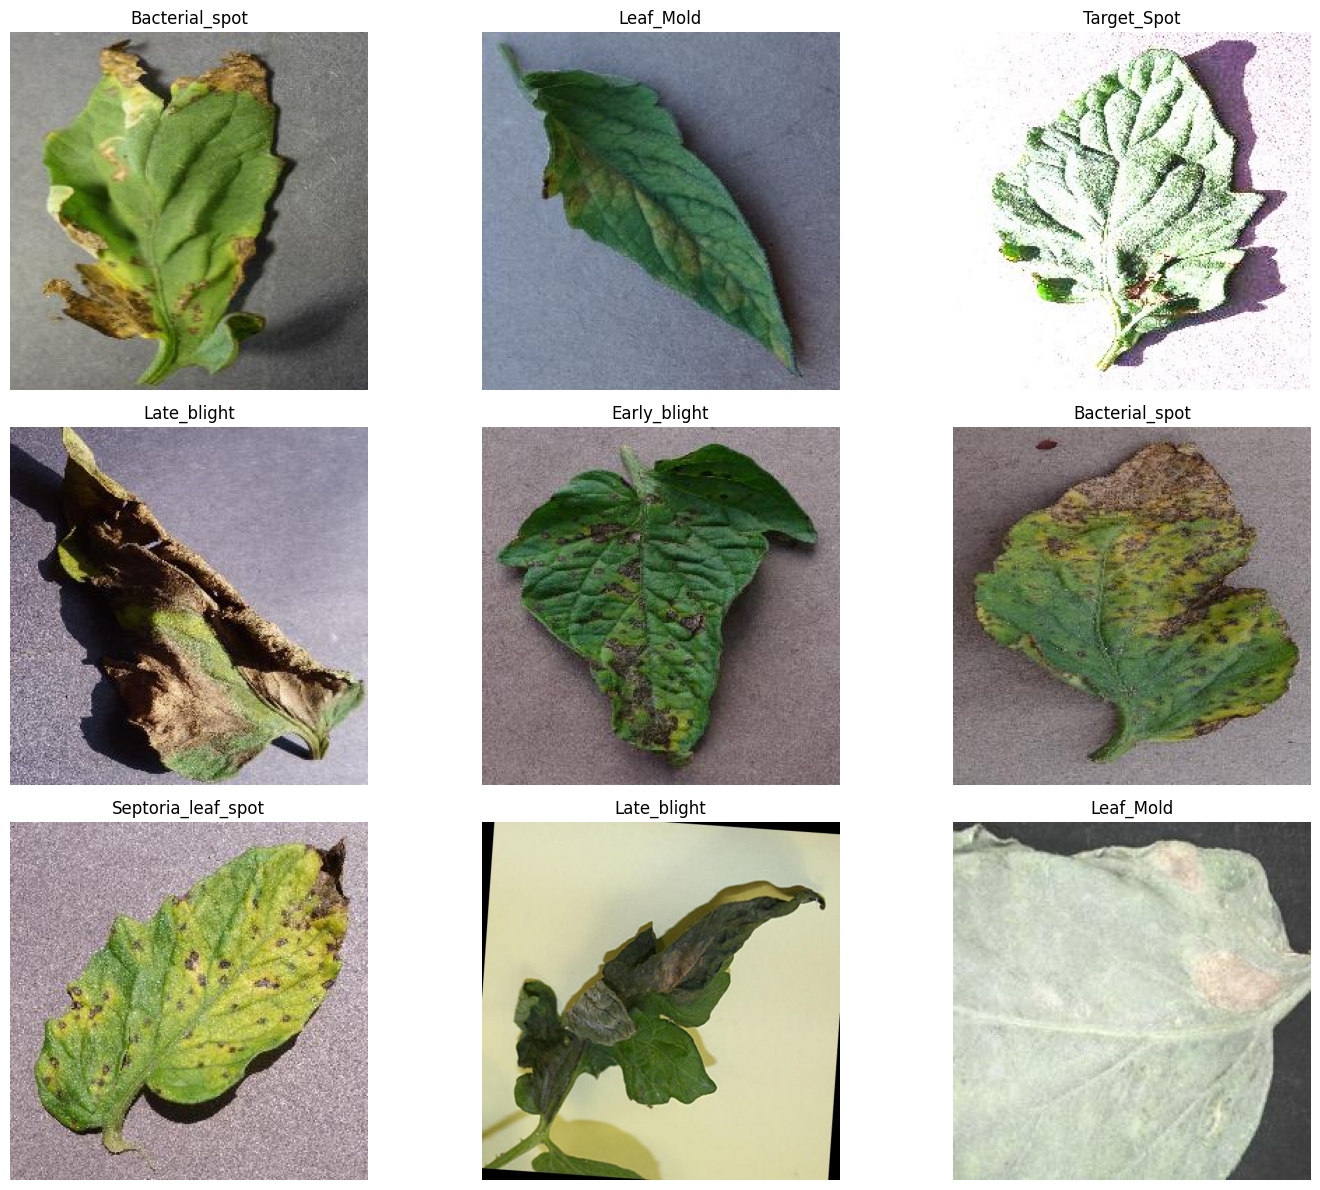

In [17]:
train_samples = show_samples(train_df)

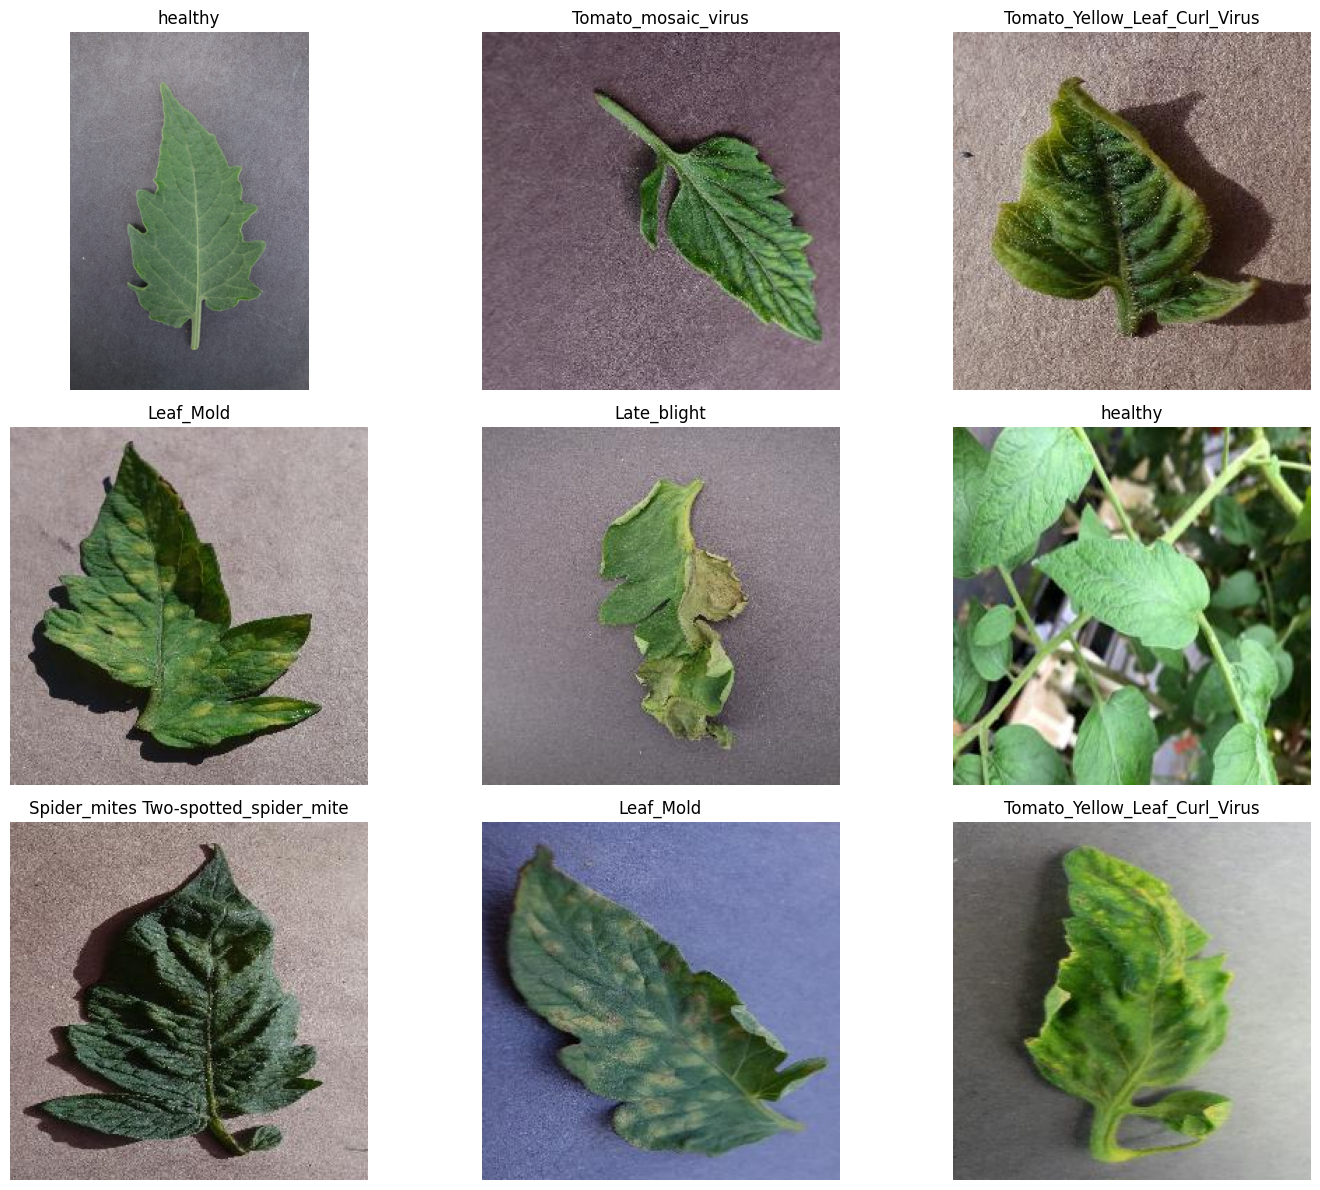

In [18]:
valid_samples = show_samples(valid_df)

In [19]:
def get_image_size_distribution(df, path_col, name="Train"):
    widths = []
    heights = []

    for path in df[path_col]:
        try:
            with Image.open(path) as img:
                widths.append(img.width)
                heights.append(img.height)
        except:
            pass

    data = pd.DataFrame({'Width': widths, 'Height': heights})
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 6))
    
    sns.boxenplot(data=data[['Width']], ax=axes[0])
    axes[0].set_title('Image Width Distribution')
    axes[0].set_ylabel("Width in pixels")

    sns.boxenplot(data=data[['Height']], ax=axes[1])
    axes[1].set_title('Image Height Distribution')
    axes[1].set_ylabel("Height in pixels")
    
    plt.tight_layout()
    plt.show()

    print(f"{name} dataset - Average Width in pixels: {np.mean(widths):.2f}")
    print(f"{name} dataset - Median Width in pixels: {np.median(widths):.2f}")
    print(f"{name} dataset - Average Height in pixels: {np.mean(heights):.2f}")
    print(f"{name} dataset - Median Height in pixels: {np.median(heights):.2f}")
    print(f"{name} dataset - Min Dimensions in pixels: {min(widths)}x{min(heights)}")
    print(f"{name} dataset - Max Dimensions in pixels: {max(widths)}x{max(heights)}")

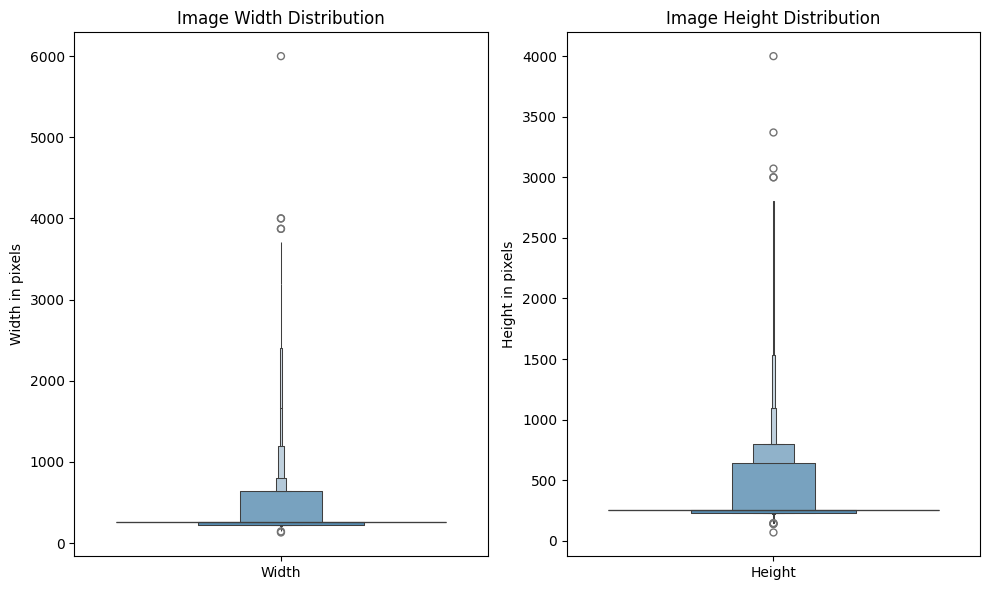

Train dataset - Average Width in pixels: 292.72
Train dataset - Median Width in pixels: 256.00
Train dataset - Average Height in pixels: 301.86
Train dataset - Median Height in pixels: 256.00
Train dataset - Min Dimensions in pixels: 130x69
Train dataset - Max Dimensions in pixels: 6000x4000


In [20]:
get_image_size_distribution(df=train_df, path_col="path", name="Train")

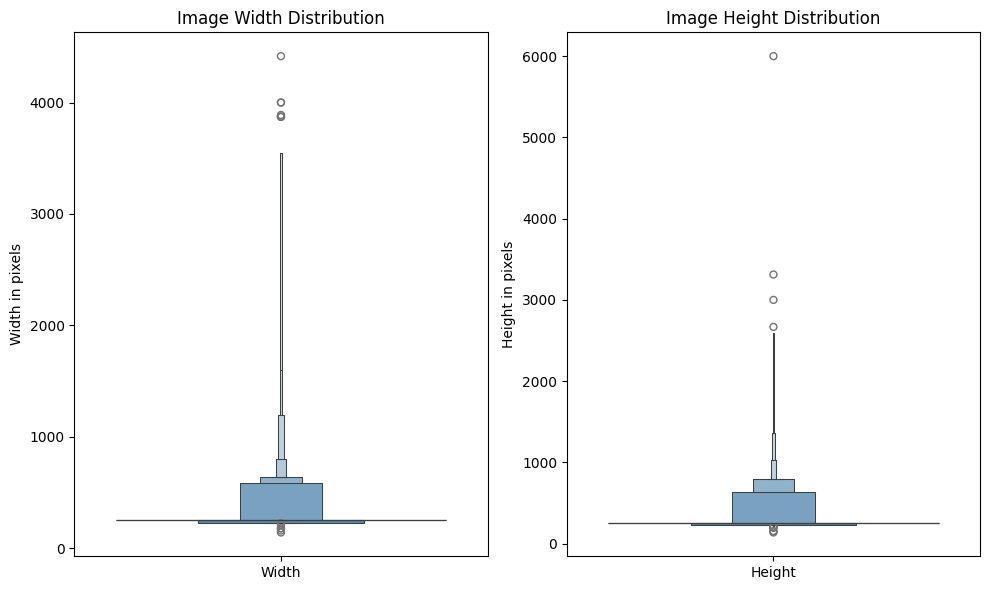

Validation dataset - Average Width in pixels: 291.90
Validation dataset - Median Width in pixels: 256.00
Validation dataset - Average Height in pixels: 300.55
Validation dataset - Median Height in pixels: 256.00
Validation dataset - Min Dimensions in pixels: 142x137
Validation dataset - Max Dimensions in pixels: 4416x6000


In [21]:
get_image_size_distribution(df=valid_df, path_col="path", name="Validation")

# Custom dataset creation

In [22]:
class ImageDataset(Dataset):
  def __init__(self, df, label_to_id, transform=None):
    self.df = df
    self.label_to_id = label_to_id
    self.transform = transform

  def __len__(self):
    return len(self.df)

  def __getitem__(self, idx):
    img_path = self.df.iloc[idx]["path"]
    image = Image.open(img_path).convert("RGB")
    label = self.label_to_id[self.df.iloc[idx]["label"]]

    if self.transform:
      image = self.transform(image)

    return image, label

In [23]:
transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.ToTensor(),
    transforms.Normalize(mean= [0.485, 0.456, 0.406], std= [0.229, 0.224, 0.225])]
)

In [24]:
train_image_dataset = ImageDataset(df=train_df, label_to_id=train_and_validation_classes, transform=transform)
validation_image_dataset = ImageDataset(df=valid_df, label_to_id=train_and_validation_classes, transform=transform)
test_image_dataset = ImageDataset(df=test_df, label_to_id=test_classes, transform=transform)


In [25]:
train_image_loader = DataLoader(dataset=train_image_dataset, batch_size=32, shuffle=True)
validation_image_loader = DataLoader(dataset=validation_image_dataset, batch_size=32, shuffle=True)
test_image_loader = DataLoader(dataset=test_image_dataset, batch_size=32, shuffle=True)

In [26]:
for img, id in train_image_loader:
  print(img.shape, id.shape)
  break

torch.Size([32, 3, 256, 256]) torch.Size([32])


In [27]:
train_dict = {v:k for k, v in train_image_dataset.label_to_id.items()}
test_dict = {v:k for k, v in test_image_dataset.label_to_id.items()}
validation_dict = {v:k for k, v in validation_image_dataset.label_to_id.items()}

torch.Size([32, 3, 256, 256]) torch.Size([32])
(3, 256, 256)
Early_blight
(256, 256, 3)
1


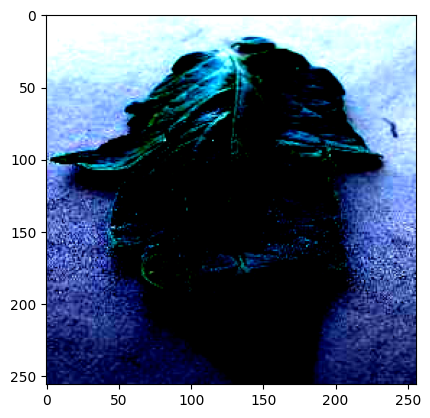

In [29]:
for images, labels in train_image_loader:
  print(images.shape, labels.shape)
  img = images[0].numpy()
  print(img.shape)
  label = labels[0].item()
  print(train_dict[label])
  img = np.transpose(img, (1,2,0))
  print(img.shape)
  print(label)
  plt.imshow(img)
  break

In [30]:
class CustomCnnModel(nn.Module):
  def __init__(self,input_dim, num_classes):
    super(CustomCnnModel, self).__init__()
    self.input_dim = input_dim
    self.num_classes = num_classes

    self.conv_layers = nn.Sequential(
        # C1
        nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1),
        # 128x128x3 --> 3x3x3x32 --> wxhx32
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # C2
        nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # C3
        nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(128),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),

        # C4
        nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
        nn.BatchNorm2d(256),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )

    self._to_linear = None
    self._get_conv_output(self.input_dim)

    self.fc_layers = nn.Sequential(
        nn.Linear(self._to_linear, 512),
        nn.ReLU(),
        # nn.Dropout(0.2)
        nn.Linear(512, 128),
        nn.ReLU(),
        nn.Linear(128, self.num_classes),
    )

    # 256 x 12 x 12

  def _get_conv_output(self, input_dim=128):
    with torch.no_grad():
      dummy_input = torch.zeros(1,3, input_dim, input_dim)
      output = self.conv_layers(dummy_input)
      self._to_linear = output.view(1, -1).size(1)

  def forward(self,x):
    x = self.conv_layers(x)
    x = x.view(x.size(0), -1)
    x = self.fc_layers(x)
    return x

In [31]:
num_train_classes = len(train_and_validation_classes)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CustomCnnModel(input_dim=256, num_classes=num_train_classes).to(device)

In [32]:
print(device)

cuda


In [33]:
print(summary(model, (3,256,256)))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 256, 256]             896
       BatchNorm2d-2         [-1, 32, 256, 256]              64
              ReLU-3         [-1, 32, 256, 256]               0
         MaxPool2d-4         [-1, 32, 128, 128]               0
            Conv2d-5         [-1, 64, 128, 128]          18,496
       BatchNorm2d-6         [-1, 64, 128, 128]             128
              ReLU-7         [-1, 64, 128, 128]               0
         MaxPool2d-8           [-1, 64, 64, 64]               0
            Conv2d-9          [-1, 128, 64, 64]          73,856
      BatchNorm2d-10          [-1, 128, 64, 64]             256
             ReLU-11          [-1, 128, 64, 64]               0
        MaxPool2d-12          [-1, 128, 32, 32]               0
           Conv2d-13          [-1, 256, 32, 32]         295,168
      BatchNorm2d-14          [-1, 256,

In [34]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=0.001)

In [35]:
len(train_image_loader)

606

In [47]:
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.best_score = None
        self.counter = 0
        self. best_model_state = None
        
    def step(self, score, model):
        if self.best_score is None or score > self.best_score:
            self.best_score = score
            self.counter = 0
            self.best_model_state = model.state_dict()
        else:
            self.counter += 1
            
        return self.counter >= self.patience

In [36]:
# Training loop
epochs = 40
for epoch in range(epochs):
  model.train()
  running_loss = 0.0
  for images, labels in train_image_loader:
    images,labels = images.to(device), labels.to(device).long()
    optimizer.zero_grad()
    outputs = model(images)
    # [x, 3, 128, 128]

    loss = criterion(outputs, labels)
    loss.backward()
    optimizer.step()
    running_loss+=loss.item()
  print(f"Epoch {epoch+1}/{epochs}, Loss : {running_loss/len(train_image_loader)}")
  
torch.save(model.state_dict(), "models/cnn_model_40.pth")

Epoch 1/40, Loss : 1.369040142093161
Epoch 2/40, Loss : 0.7148415053589116
Epoch 3/40, Loss : 0.575254097925161
Epoch 4/40, Loss : 0.47532325828134425
Epoch 5/40, Loss : 0.41064720618055994
Epoch 6/40, Loss : 0.3610454144835374
Epoch 7/40, Loss : 0.31952469029061176
Epoch 8/40, Loss : 0.2713215616700722
Epoch 9/40, Loss : 0.2367964204333157
Epoch 10/40, Loss : 0.19699219654532452
Epoch 11/40, Loss : 0.16762409205840464
Epoch 12/40, Loss : 0.14630131480182604
Epoch 13/40, Loss : 0.12008854825081912
Epoch 14/40, Loss : 0.10675709307994448
Epoch 15/40, Loss : 0.08450624141776811
Epoch 16/40, Loss : 0.0746742869213338
Epoch 17/40, Loss : 0.08260279479169551
Epoch 18/40, Loss : 0.07857794116649595
Epoch 19/40, Loss : 0.06729155217092112
Epoch 20/40, Loss : 0.05178696767770606
Epoch 21/40, Loss : 0.059633090788464516
Epoch 22/40, Loss : 0.045334687216742206
Epoch 23/40, Loss : 0.04901764356233225
Epoch 24/40, Loss : 0.053107733564691374
Epoch 25/40, Loss : 0.04778699224232504
Epoch 26/40, Lo

In [ ]:
def my_train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=10, save_path="best_model.pth"):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    mlflow.log_params({"epochs": epochs})
    
    train_acc_metric = Accuracy(task="multiclass", num_classes=11).to(device)
    val_acc_metric = Accuracy(task="multiclass", num_classes=11).to(device)

    train_loss_metric = MeanMetric().to(device)
    val_loss_metric = MeanMetric().to(device)

    history = {"train_loss":[], "val_loss":[], "val_acc":[]}
    best_accuracy = 0.0
    best_model_weights = copy.deepcopy(model.state_dict())

    train_bar = tqdm(range(epochs), desc="Total Progress", leave=True)
    for epoch in train_bar:
        print(f"Epoch {epoch + 1}/{epochs}")
        print("-" * 10)
    
        model.train()
        
        for images, labels in tqdm(train_loader, desc="Training", leave=False):
            images = images.to(device)
            labels = labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss_metric.update(loss)
            train_acc_metric.update(outputs, labels)

            train_bar.set_postfix(loss=loss.item())

        epoch_train_loss = train_loss_metric.compute()
        epoch_train_acc = train_acc_metric.compute()
        train_loss_metric.reset()
        train_acc_metric.reset()

        model.eval()
        
        val_bar = tqdm(val_loader, desc="Validation", leave=False)

        with torch.inference_mode():
            for images, labels in val_bar:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss_metric.update(loss)
                val_acc_metric.update(outputs, labels)

            epoch_val_loss = val_loss_metric.compute()
            epoch_val_acc = val_acc_metric.compute()
            val_loss_metric.reset()
            val_acc_metric.reset()

            history['train_loss'].append(epoch_train_loss.item())
            history['val_loss'].append(epoch_val_loss.item())
            history['val_acc'].append(epoch_val_acc.item())
            
            mlflow.log_metrics({
                "train_loss": epoch_train_loss.item(),
                "val_loss": epoch_val_loss.item(),
                "val_acc": epoch_val_acc.item()
                },
                step=epoch)

        
            if scheduler:
                scheduler.step()

            print(f'Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {epoch_val_acc:.4f}')
 
            # --- Checkpointing ---
            if epoch_val_acc > best_accuracy:
                best_accuracy = epoch_val_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                torch.save(model.state_dict(), save_path)
                print(f"--> New Best Model Saved (Acc: {best_accuracy:.4f})")

        print(f'Training complete. Best Validation Accuracy: {best_accuracy:.4f}')
        model.load_state_dict(best_model_wts)
        
    mlflow.pytorch.log_model(model, name="MLflow_tracked_VGG")
    
    return model, history

    

In [37]:
model = CustomCnnModel(input_dim=256, num_classes=num_train_classes).to(device=device)

model.load_state_dict(torch.load("models/cnn_model_40.pth"))
print(model.state_dict())

OrderedDict({'conv_layers.0.weight': tensor([[[[ 2.9330e-01,  2.1746e-01, -1.6581e-01],
          [ 2.4497e-01,  5.1329e-02, -1.0908e-01],
          [ 4.9218e-02,  2.1559e-01,  1.8592e-01]],

         [[ 8.7114e-02, -1.0092e-01, -2.3236e-01],
          [ 4.3467e-02,  5.1658e-03, -7.2543e-02],
          [ 2.0570e-01, -4.3913e-02, -5.0060e-02]],

         [[-1.3847e-01, -5.7294e-02, -3.1922e-01],
          [-1.2285e-01, -1.9118e-02, -2.8795e-01],
          [-3.0611e-01, -2.4585e-01, -3.2857e-01]]],


        [[[ 3.7864e-01,  3.0093e-01,  4.8078e-01],
          [ 1.2182e-01,  2.6926e-01,  2.1756e-01],
          [-1.9262e-01, -2.1373e-02,  1.1905e-01]],

         [[-1.4936e-01,  2.4008e-01,  1.4857e-01],
          [-1.9905e-01,  4.2946e-02, -3.8501e-02],
          [-4.4536e-02, -2.3325e-01, -1.9123e-01]],

         [[-4.2413e-02, -2.2338e-02, -1.0692e-02],
          [-1.0652e-01,  1.4369e-01,  2.2477e-01],
          [-1.2131e-01,  1.1290e-01, -6.7944e-02]]],


        [[[-6.0126e-01, -6.97

In [38]:
print(model)

CustomCnnModel(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_sta

In [39]:
for images, labels in validation_image_loader:
  print(labels.shape)
  break

torch.Size([32])


In [41]:
# Evaluate model

model.eval()
correct = 0
total = 0

with torch.no_grad():
  for images, labels in validation_image_loader:
    images,labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print(f"Validation accuracy is :{100* correct / total:.2f}%")

Validation accuracy is :89.70%


In [ ]:
# Evaluate model
ImageFile.LOAD_TRUNCATED_IMAGES = True # Must be set because test set (validation folder) contains truncated images
model.eval()
correct = 0
total = 0

with torch.no_grad():
  for images, labels in test_image_loader:
    images,labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)
    total += labels.size(0)
    correct += (predicted == labels).sum().item()

print(f"Test accuracy is :{100* correct / total:.2f}%")

Test accuracy is :90.65%
